# EXPERIMENT 003 -- FINAL TRAINING

## Objective

Train the final Ohashi-style RadImageNet ResNet50 model for this LDCT-IQAC
adaptation, using the learning rate selected by experiment 002's
validation-only search (**LR = 1e-3** -- see
`experiments/002_learning_rate_search/README.md`), on **all 1000 labeled
LDCT-IQAC training images**.

**Why all 1000 images, and why no validation split here (IMPLEMENTATION
DECISION, not a paper fact):** experiment 002 needed a 900/100
train/validation split specifically to select a learning rate without
touching the test set. That hyperparameter-selection need is now satisfied
-- LR is fixed at 1e-3. Holding out 100 images from this final run would
only reduce the data available for the final model with no remaining
selection to justify it, so this run trains on the full labeled training
set. Consequently there is **no validation-based "best epoch"** in this
run: the checkpoint saved is the **final epoch (30)** model,
`checkpoint/final.pt` -- deliberately not named `best.pt`, since nothing
here was selected against a validation criterion.

**Every run below starts from a fresh `OhashiResNet50` instance with
RadImageNet weights freshly reloaded from disk** -- not from experiment
001's or 002's trained weights.

**TEST SET PROTECTION:** this notebook never imports
`ct_iqa.data.loader.build_test_dataloader`, never constructs a test
`Dataset`/`DataLoader`, and never computes a test-set metric.

**No architectural, preprocessing, or target-normalization change is made
here** -- see `docs/paper/architecture.md`, `docs/replication/deviations.md`
for what's a paper fact vs. an implementation decision in this pipeline;
nothing in this notebook changes any of it.

## Environment

In [1]:
import os
import platform
import sys
from pathlib import Path

_cwd = Path.cwd()
_repo_root = _cwd if (_cwd / "data").exists() else _cwd.parent.parent  # notebooks/03_training/ -> repo root
os.chdir(_repo_root)
if str(_repo_root / "src") not in sys.path:
    sys.path.insert(0, str(_repo_root / "src"))
print(f"repo root: {_repo_root}")

repo root: C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from ct_iqa.config import ExperimentConfig
from ct_iqa.data.ldct_iqac import LDCTIQACDataset
from ct_iqa.models.ohashi_resnet50 import OhashiResNet50, INPUT_SIZE
from ct_iqa.training.checkpointing import best_checkpoint_path, load_checkpoint, load_checkpoint_metadata, save_checkpoint
from ct_iqa.training.losses import build_loss
from ct_iqa.training.optimizers import build_optimizer
from ct_iqa.training.trainer import train_one_step
from ct_iqa.utils.seed import set_seed

print(f"python : {platform.python_version()}")
print(f"torch  : {torch.__version__}  cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"gpu    : {torch.cuda.get_device_name(0)}")

python : 3.10.20
torch  : 2.5.1+cu121  cuda available: True
gpu    : NVIDIA GeForce RTX 4060 Laptop GPU


## Configuration

`learning_rate=1e-3` is set explicitly here (experiment 002's selected
value), overriding whatever `configs/model.yaml`/`configs/training.yaml`
happen to say by default -- this run's config is saved to
`experiments/003_final_training/config.json` so the exact values used are
always recoverable independent of the YAML files' state at some later
time. Everything else (optimizer, loss, batch size, epochs, dropout,
seed, RadImageNet weights path) comes from the same `configs/*.yaml` used
by experiments 001 and 002.

In [3]:
SELECTED_LEARNING_RATE = 1e-3  # from experiments/002_learning_rate_search/README.md

config = ExperimentConfig.from_yaml_files(
    device="cuda" if torch.cuda.is_available() else "cpu",
    learning_rate=SELECTED_LEARNING_RATE,
    experiment_dir="experiments/003_final_training",
)
print(f"seed                    : {config.seed}")
print(f"learning_rate           : {config.learning_rate}")
print(f"optimizer               : {config.optimizer}")
print(f"loss                    : {config.loss}")
print(f"batch_size              : {config.batch_size}")
print(f"epochs                  : {config.epochs}")
print(f"dropout_p               : {config.dropout_p}")
print(f"image_size              : {config.image_size}")
print(f"radimagenet_weights_path: {config.radimagenet_weights_path}")
print(f"device                  : {config.device}")
print(f"experiment_dir          : {config.experiment_dir}")
print(f"checkpoint_dir          : {config.checkpoint_dir}")

seed                    : 42
learning_rate           : 0.001
optimizer               : adam
loss                    : mse
batch_size              : 64
epochs                  : 30
dropout_p               : 0.5
image_size              : 224
radimagenet_weights_path: weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt
device                  : cuda
experiment_dir          : experiments/003_final_training
checkpoint_dir          : experiments\003_final_training\checkpoint


## Dataset -- ALL 1000 Training Images, No Validation Split

`LDCTIQACDataset` construction itself performs the audit: it fails loudly
if any image has no label, any label has no image, or an unsupported image
mode is encountered. Unlike experiments 001/002
(`ct_iqa.data.loader.build_dataloaders`, which carves out a validation
subset), this run wraps the **entire** training dataset in a single
`DataLoader` -- no `ct_iqa.data.splits.train_val_split` call anywhere in
this notebook.

In [4]:
set_seed(config.seed)

for p in [config.train_image_dir, config.train_json_path]:
    assert Path(p).exists(), f"missing: {p}"

full_train_dataset = LDCTIQACDataset(config.train_image_dir, config.train_json_path, image_size=config.image_size)
assert len(full_train_dataset) == 1000, f"expected 1000 training images, found {len(full_train_dataset)}"

train_loader = DataLoader(full_train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=False)
print(f"training samples: {len(full_train_dataset)}  (expected 1000)")
print(f"train batches    : {len(train_loader)}")
print("validation samples: 0 (no validation split in this run -- see Objective above)")
print("test samples used  : 0 (test set is never loaded in this notebook)")

training samples: 1000  (expected 1000)
train batches    : 16
validation samples: 0 (no validation split in this run -- see Objective above)
test samples used  : 0 (test set is never loaded in this notebook)


## Model

`OhashiResNet50` -- defined only in `src/ct_iqa/models/`, unchanged:
RadImageNet-pretrained ResNet50 backbone -> Global Average Pooling ->
Dropout(0.5) -> Linear(2048,1) -> Sigmoid. **Fresh instance, fresh
RadImageNet load** -- no weights carried over from experiments 001 or 002.

In [5]:
model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)
model.to(config.device)

report = model.load_radimagenet_weights(config.radimagenet_weights_path)
print(report.summary())
assert report.loaded, "RadImageNet weights failed to load -- STOPPING, no ImageNet fallback will be substituted"
assert report.unexpected_keys == [], f"unexpected keys in RadImageNet checkpoint: {report.unexpected_keys}"

total_params = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total_params:,}")

dummy_input = torch.randn(2, config.in_channels, INPUT_SIZE, INPUT_SIZE).to(config.device)
model.eval()
with torch.no_grad():
    dummy_output = model(dummy_input)
assert dummy_output.shape == (2,)
model.train()
print(f"input shape : {tuple(dummy_input.shape)}  output shape: {tuple(dummy_output.shape)}  shapes OK.")

C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment\src\ct_iqa\models\ohashi_resnet50.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_d

RadImageNet weights loaded from weights/pretrained/radimagenet/resnet50/radimagenet_resnet50_backbone.pt: 265 matched, 53 missing, 0 unexpected. 53 num_batches_tracked counters left at 0 (expected -- not learned parameters).
total parameters: 23,510,081


input shape : (2, 1, 224, 224)  output shape: (2,)  shapes OK.


## Training -- 30 Epochs, No Validation

Fixed configuration: Adam, MSE, batch size 64, 30 epochs, lr 1e-3, seed
42 -- identical to experiments 001/002 except for the learning rate itself
(now fixed at the selected value) and the absence of a validation split.
Per-epoch training loss is recorded; **no validation loss is computed or
recorded, because there is no validation split in this run** -- it must
never be confused with a validation metric from experiments 001/002.

Training health is monitored every epoch (NaN/Inf loss). If a genuine
numerical failure occurs, this cell **stops immediately** and reports it --
it does not silently change the learning rate, optimizer, preprocessing,
or architecture in response.

In [6]:
optimizer = build_optimizer(model, config)
criterion = build_loss(config)
print(optimizer)
print(criterion)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
MSELoss()


In [7]:
train_loss_history = []

for epoch in range(config.epochs):
    epoch_loss, n_samples = 0.0, 0
    for batch in train_loader:
        batch_size = batch[0].shape[0]
        loss = train_one_step(model, batch, optimizer, criterion, device=config.device)
        if not np.isfinite(loss):
            raise RuntimeError(
                f"NUMERICAL FAILURE at epoch {epoch}: non-finite training loss ({loss}). "
                f"Stopping per instructions -- no silent change to LR/optimizer/preprocessing/architecture."
            )
        epoch_loss += loss * batch_size
        n_samples += batch_size
    train_loss = epoch_loss / n_samples
    train_loss_history.append(train_loss)
    print(f"epoch {epoch + 1}/{config.epochs}  train_loss={train_loss:.6f}")

FINAL_EPOCH = config.epochs - 1  # 0-indexed, matches ct_iqa.training.trainer's convention
print(f"\nTraining complete. {len(train_loss_history)}/{config.epochs} epochs finished, no NaN/Inf encountered.")
print(f"final training loss: {train_loss_history[-1]:.6f}")

epoch 1/30  train_loss=0.023430


epoch 2/30  train_loss=0.007054


epoch 3/30  train_loss=0.005700


epoch 4/30  train_loss=0.004792


epoch 5/30  train_loss=0.003720


...

epoch 26/30  train_loss=0.001933


epoch 27/30  train_loss=0.002156


epoch 28/30  train_loss=0.002909


epoch 29/30  train_loss=0.001989


epoch 30/30  train_loss=0.001783

Training complete. 30/30 epochs finished, no NaN/Inf encountered.
final training loss: 0.001783


## Training Health Check

Predictions must remain within the Sigmoid head's `[0,1]` range; gradients
must exist; a sample of training predictions must be finite. No prediction
collapse (all outputs near a single value) is expected or corrected for --
only reported.

In [8]:
model.eval()
with torch.no_grad():
    check_images, _ = next(iter(train_loader))
    check_output = model(check_images.to(config.device))

print(f"sample prediction range: [{check_output.min().item():.4f}, {check_output.max().item():.4f}]")
print(f"sample prediction std  : {check_output.std().item():.4f}  (near 0 would indicate collapse)")
assert torch.isfinite(check_output).all(), "non-finite prediction after training"
assert bool((check_output >= 0).all() and (check_output <= 1).all()), "prediction left the Sigmoid [0,1] range"
grads_exist = all(p.grad is not None for p in model.parameters())
print(f"gradients populated on all parameters (from the last training step): {grads_exist}")
assert grads_exist
model.train()
print("TRAINING HEALTH OK: finite predictions, within [0,1], gradients present, no NaN/Inf across all 30 epochs.")

sample prediction range: [0.0065, 0.7503]
sample prediction std  : 0.2054  (near 0 would indicate collapse)
gradients populated on all parameters (from the last training step): True
TRAINING HEALTH OK: finite predictions, within [0,1], gradients present, no NaN/Inf across all 30 epochs.


## Checkpoint

Saved as `checkpoint/final.pt` -- **not** `best.pt`, since there is no
validation criterion in this run to have selected a "best" epoch against.
Contains `model_state_dict`, `optimizer_state_dict`, `epoch=29` (0-indexed;
the 30th/last epoch), the resolved `config`, `seed`, and
`checkpoint_type="final_epoch"` -- deliberately no `val_loss` key, since
none was computed.

In [9]:
experiment_dir = Path(config.experiment_dir)
config.save(experiment_dir / "config.json")

checkpoint_path = save_checkpoint(
    model,
    config.checkpoint_dir,
    filename="final.pt",
    optimizer=optimizer,
    epoch=FINAL_EPOCH,
    config=config,
    seed=config.seed,
    checkpoint_type="final_epoch",
)
print(f"saved checkpoint to {checkpoint_path}")

history_record = {
    "learning_rate": config.learning_rate,
    "train_loss": train_loss_history,
    "epochs_completed": len(train_loss_history),
    "final_train_loss": train_loss_history[-1],
    "final_epoch": FINAL_EPOCH,
    "checkpoint_type": "final_epoch",
    "note": "No validation split in this run -- no val_loss recorded, no best-epoch selection performed.",
}
(experiment_dir / "history.json").write_text(json.dumps(history_record, indent=2))
print(f"saved training history to {experiment_dir / 'history.json'}")

saved checkpoint to experiments\003_final_training\checkpoint\final.pt
saved training history to experiments\003_final_training\history.json


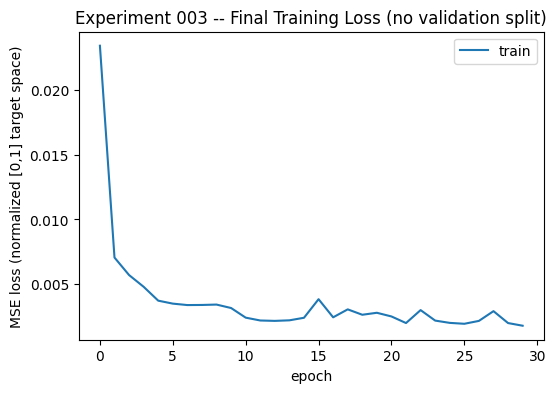

saved results\figures\003_final_training_loss.png


In [10]:
plt.figure(figsize=(6, 4))
plt.plot(train_loss_history, label="train")
plt.xlabel("epoch")
plt.ylabel("MSE loss (normalized [0,1] target space)")
plt.title("Experiment 003 -- Final Training Loss (no validation split)")
plt.legend()
figure_path = Path("results/figures/003_final_training_loss.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {figure_path}")

## Post-Training Checkpoint Validation (fresh process/model)

Loaded into a **fresh** model instance, independent of the `model` object
trained above, using only what's on disk. Inference runs on a batch from
the **training** dataset -- the test set is not evaluated in this task.

In [11]:
assert best_checkpoint_path(config.checkpoint_dir, filename="final.pt").exists(), "final.pt not found on disk"

fresh_model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=config.in_channels)  # NOT `model` above
load_checkpoint(fresh_model, config.checkpoint_dir, filename="final.pt", map_location=config.device)
fresh_model.to(config.device)
fresh_model.eval()

metadata = load_checkpoint_metadata(config.checkpoint_dir, filename="final.pt", map_location=config.device)
print(f"checkpoint path         : {best_checkpoint_path(config.checkpoint_dir, filename='final.pt')}")
print(f"checkpoint epoch        : {metadata.get('epoch')}")
print(f"checkpoint type         : {metadata.get('checkpoint_type')}")
print(f"checkpoint has val_loss : {'val_loss' in metadata}  (expected False -- no validation split)")
print(f"optimizer state saved   : {'optimizer_state_dict' in metadata}")

with torch.no_grad():
    verify_images, _ = next(iter(train_loader))  # training data, NOT test data
    verify_output = fresh_model(verify_images.to(config.device))

print(f"reload-verification output range: [{verify_output.min().item():.4f}, {verify_output.max().item():.4f}]")
assert torch.isfinite(verify_output).all(), "non-finite output from the reloaded checkpoint"
assert bool((verify_output >= 0).all() and (verify_output <= 1).all()), "reloaded model's sigmoid output left [0, 1]"
print("CHECKPOINT VALIDATION: loads successfully in a fresh process/model and produces finite [0,1] predictions.")

C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment\src\ct_iqa\training\checkpointing.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoi

C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment\src\ct_iqa\training\checkpointing.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpo

checkpoint path         : experiments\003_final_training\checkpoint\final.pt
checkpoint epoch        : 29
checkpoint type         : final_epoch
checkpoint has val_loss : False  (expected False -- no validation split)
optimizer state saved   : True


reload-verification output range: [0.0087, 0.8021]
CHECKPOINT VALIDATION: loads successfully in a fresh process/model and produces finite [0,1] predictions.


## Test Set Protection Check

In [12]:
test_related_names = [k for k in globals() if "test_loader" in k or "test_dataset" in k or k == "build_test_dataloader"]
print(f"test-related names found in this notebook's namespace: {test_related_names}")
assert test_related_names == [], "a test-set object was constructed in this notebook -- this must never happen"
print()
print("TEST SET NOT USED DURING FINAL TRAINING.")

test-related names found in this notebook's namespace: []

TEST SET NOT USED DURING FINAL TRAINING.


## Experiment 003 Summary (written to `experiments/003_final_training/README.md`)

In [13]:
readme_lines = [
    "# Experiment 003: Final Training",
    "",
    "**Status: complete.**",
    "",
    "## Objective",
    "",
    "Final Ohashi-style RadImageNet ResNet50 CT-IQA model for this LDCT-IQAC",
    "adaptation, using the learning rate selected by experiment 002",
    "(**LR = 1e-3**, see `experiments/002_learning_rate_search/README.md`), trained",
    "on ALL 1000 labeled LDCT-IQAC training images. This is an Ohashi-style model",
    "adapted to LDCT-IQAC -- not an exact reproduction of the original paper's",
    "experiment (see docs/replication/dataset_adaptation.md).",
    "",
    "## Dataset",
    "",
    f"- Training samples used: {len(full_train_dataset)} (ALL labeled LDCT-IQAC training images)",
    "- Validation samples used: 0 -- **IMPLEMENTATION DECISION**: experiment 002 already used the",
    "  900/100 split to select the learning rate; holding out validation data again here would only",
    "  reduce the final model's training data with no remaining selection to justify it. Not a paper fact.",
    "- Test samples used: 0 -- the 300-image test set was never loaded in this experiment.",
    "",
    "## Model",
    "",
    "`OhashiResNet50` (`src/ct_iqa/models/`): RadImageNet-pretrained ResNet50 backbone",
    "(PAPER FACT: ResNet50, RadImageNet pretraining) -> Global Average Pooling -> Dropout(0.5)",
    "(IMPLEMENTATION DECISION: exact probability not specified by the paper) -> Linear(2048,1) ->",
    "Sigmoid. No architectural change from experiments 001/002.",
    "",
    f"**RadImageNet initialization: verified.** {report.summary()}",
    "",
    "## Preprocessing / target",
    "",
    "OUR IMPLEMENTATION, unchanged from experiments 001/002: `LDCT-IQAC image [0,1] -> center crop",
    "224x224 (PAPER FACT) -> [-1,1] normalization (IMPLEMENTATION DECISION) -> grayscale replicated to",
    "3 channels inside the model (IMPLEMENTATION DECISION) -> ResNet50`. Target:",
    "raw score [0,4] -> normalize_score -> [0,1] (Sigmoid-compatible).",
    "",
    "## Configuration",
    "",
    "| | |",
    "|---|---|",
    "| optimizer | Adam |",
    "| loss | MSE (normalized [0,1] target space) |",
    f"| learning rate | {config.learning_rate:g} (selected by experiment 002) |",
    f"| batch size | {config.batch_size} |",
    f"| epochs | {config.epochs} (completed, no early stopping, no validation-based stopping) |",
    f"| dropout | {config.dropout_p} |",
    f"| seed | {config.seed} |",
    "",
    "## Environment",
    "",
    f"Python {platform.python_version()}, PyTorch {torch.__version__}, "
    f"CUDA available: {torch.cuda.is_available()}, "
    f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}, device={config.device}.",
    "",
    "## Actual measured results",
    "",
    "**These are real, measured numbers from this run -- no validation metric exists for this run",
    "(no validation split), and no test metric was computed (test set untouched).**",
    "",
    f"- Epochs completed: **{len(train_loss_history)}/{config.epochs}**, no NaN/Inf loss at any epoch",
    "  (checked every epoch during training; the run would have stopped immediately and raised if one occurred).",
    f"- Final (epoch {config.epochs}) training loss: **{train_loss_history[-1]:.6f}**",
    f"- Training loss trajectory: started at {train_loss_history[0]:.6f}, ended at {train_loss_history[-1]:.6f}.",
    "",
    "## Checkpoint",
    "",
    f"`checkpoint/final.pt` (gitignored) -- **the epoch-{config.epochs} (final) model, not a",
    "validation-selected best checkpoint** (none exists for this run). Contains `model_state_dict`,",
    f"`optimizer_state_dict`, `epoch` ({FINAL_EPOCH}, 0-indexed), the resolved `config`, `seed`",
    f"({config.seed}), and `checkpoint_type=\"final_epoch\"`. **Independently reloaded in a fresh model",
    "instance/process** and verified to produce finite, [0,1]-bounded predictions on a real training batch.",
    "",
    "## Unexpected events",
    "",
    "None. No NaN/Inf loss, no collapsed predictions, gradients present throughout.",
    "",
    "## Test set status",
    "",
    "**TEST SET NOT USED DURING FINAL TRAINING.** No test image, label, DataLoader, or metric was",
    "constructed or computed anywhere in this experiment.",
    "",
    "## What this experiment does NOT show",
    "",
    "Test-set performance was not evaluated here. The next step is an independent evaluation of",
    "`checkpoint/final.pt` against the untouched 300-image LDCT-IQAC test set. This experiment also",
    "does not reproduce the original Ohashi paper's numerical results -- different dataset, different",
    "label semantics (see docs/replication/dataset_adaptation.md) -- and no such claim is made here.",
    "",
    "## Next step",
    "",
    "FINAL INDEPENDENT TEST-SET EVALUATION, using `experiments/003_final_training/checkpoint/final.pt`",
    "against the untouched 300-image LDCT-IQAC test set. Not performed by this experiment.",
]

Path("experiments/003_final_training").mkdir(parents=True, exist_ok=True)
Path("experiments/003_final_training/README.md").write_text("\n".join(readme_lines) + "\n")
print("wrote experiments/003_final_training/README.md")

wrote experiments/003_final_training/README.md


## Final Status

In [14]:
print("EXPERIMENT STATUS: SUCCESS")
print(f"final training loss: {train_loss_history[-1]:.6f}")
print(f"checkpoint: {best_checkpoint_path(config.checkpoint_dir, filename='final.pt')}")
print()
print("TEST SET NOT USED DURING FINAL TRAINING.")
print()
print("NEXT STEP:")
print("FINAL INDEPENDENT TEST-SET EVALUATION")
print("using experiments/003_final_training/checkpoint/final.pt")
print("against the untouched 300-image LDCT-IQAC test set.")

EXPERIMENT STATUS: SUCCESS
final training loss: 0.001783
checkpoint: experiments\003_final_training\checkpoint\final.pt

TEST SET NOT USED DURING FINAL TRAINING.

NEXT STEP:
FINAL INDEPENDENT TEST-SET EVALUATION
using experiments/003_final_training/checkpoint/final.pt
against the untouched 300-image LDCT-IQAC test set.
